### RideWise RFMS Customer Segmentation

**RFMS** = Recency, Frequency, Monetry, and Surge Multiplier
* **Recency:** How recently did the customer transact?
* **Frequency:** How often do they transact?
* **Monetary:** How much do they spend?
* **Surge Multiplier:** To what extent does the customer transact during high-demand (surge-priced) periods?

In [420]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [421]:
# Load the data

df = pd.read_csv("../data/RideWise_EDA_df.csv")

# To check the number of rows and columns
print("\n📌 Dataset Shape:", df.shape)

# Print the top 5 rows
df.head()


📌 Dataset Shape: (200000, 37)


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,trip_duration_mins,rider_age_group,pickup_hour,pickup_date,pickup_day,pickup_month,pickup_year,pickup_period,drop_off_day,drop_off_date
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50+00:00,2024-11-27 17:06:50+00:00,-1.108123,...,52,Established Adults,16,2024-11-27 00:00:00+00:00,Wednesday,November,2024,Evening,Wednesday,2024-11-27 00:00:00+00:00
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,13,Established Adults,22,2024-10-28 00:00:00+00:00,Monday,October,2024,Night,Monday,2024-10-28 00:00:00+00:00
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41+00:00,2025-02-17 03:25:41+00:00,-1.248589,...,16,Established Adults,3,2025-02-17 00:00:00+00:00,Monday,February,2025,Late Night,Monday,2025-02-17 00:00:00+00:00
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 17:22:14+00:00,2024-06-18 17:27:14+00:00,29.819554,...,5,Emerging Adults,17,2024-06-18 00:00:00+00:00,Tuesday,June,2024,Evening,Tuesday,2024-06-18 00:00:00+00:00
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 07:31:16+00:00,2024-10-05 08:01:16+00:00,-1.676479,...,30,Young Professionals,7,2024-10-05 00:00:00+00:00,Saturday,October,2024,Early Morning,Saturday,2024-10-05 00:00:00+00:00


In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   trip_id             200000 non-null  object 
 1   user_id             200000 non-null  object 
 2   driver_id           200000 non-null  object 
 3   fare                200000 non-null  float64
 4   surge_multiplier    200000 non-null  float64
 5   tip                 200000 non-null  float64
 6   payment_type        200000 non-null  object 
 7   pickup_time         200000 non-null  object 
 8   dropoff_time        200000 non-null  object 
 9   pickup_lat          200000 non-null  float64
 10  pickup_lng          200000 non-null  float64
 11  dropoff_lat         200000 non-null  float64
 12  dropoff_lng         200000 non-null  float64
 13  weather             200000 non-null  object 
 14  city                200000 non-null  object 
 15  loyalty_status      200000 non-nul

In [423]:
# Parse/convert dates datatypes

# Riders signup date 
if "rider_signup_date" in df.columns:
    df["rider_signup_date"] = pd.to_datetime(
        df["rider_signup_date"],
        errors="coerce",
        utc=True
    )

# Drivers signup date
if "driver_signup_date" in df.columns:
    df["driver_signup_date"] = pd.to_datetime(
        df["driver_signup_date"],
        errors="coerce",
        utc=True
    )

# Trips pickup & dropoff times 
for col in ["pickup_time", "dropoff_time", "pickup_date", "drop_off_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col],
            errors="coerce",
            utc=True
        )
# Drivers last active
df["last_active"] = pd.to_datetime(df["last_active"], errors="coerce", utc=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   trip_id             200000 non-null  object             
 1   user_id             200000 non-null  object             
 2   driver_id           200000 non-null  object             
 3   fare                200000 non-null  float64            
 4   surge_multiplier    200000 non-null  float64            
 5   tip                 200000 non-null  float64            
 6   payment_type        200000 non-null  object             
 7   pickup_time         200000 non-null  datetime64[ns, UTC]
 8   dropoff_time        200000 non-null  datetime64[ns, UTC]
 9   pickup_lat          200000 non-null  float64            
 10  pickup_lng          200000 non-null  float64            
 11  dropoff_lat         200000 non-null  float64            
 12  dropoff_lng     

### Compute RFMS features

In [425]:
snapshot_date = df["dropoff_time"].max() + pd.Timedelta(days=1)

rfms = df.groupby("user_id").agg(
    recency_days=("dropoff_time", lambda x: (snapshot_date - x.max()).days),
    frequency=("trip_id", "count"),
    monetary=("fare", "sum"),
    surge_exposure=("surge_multiplier", lambda x: (x > 1.0).mean())
).reset_index()

print(f"RFM Table: {len(rfms):,} customers")
rfms.head(10)

RFM Table: 10,000 customers


,user_id,recency_days,frequency,monetary,surge_exposure
0,R00000,26,25,366.05,0.280000
1,R00001,6,14,180.53,0.214286
2,R00002,15,24,378.99,0.375000
3,R00003,62,9,121.47,0.333333
4,R00004,13,16,268.43,0.437500
5,R00005,3,19,274.42,0.263158
6,R00006,68,14,199.01,0.428571
7,R00007,20,19,366.09,0.368421
8,R00008,7,19,272.18,0.263158
9,R00009,81,14,253.57,0.500000


In [426]:
# Numerical Statisticcal Analysis

rfms.describe()

,recency_days,frequency,monetary,surge_exposure
count,10000.000000,10000.00000,10000.000000,10000.000000
mean,19.169700,20.00000,308.025691,0.335834
std,18.363443,4.49838,74.760409,0.108479
min,1.000000,6.00000,78.870000,0.000000
25%,6.000000,17.00000,255.260000,0.263158
50%,13.000000,20.00000,304.725000,0.333333
75%,26.000000,23.00000,356.750000,0.409091
max,175.000000,42.00000,663.910000,0.818182


### RFMS Distribution Plots

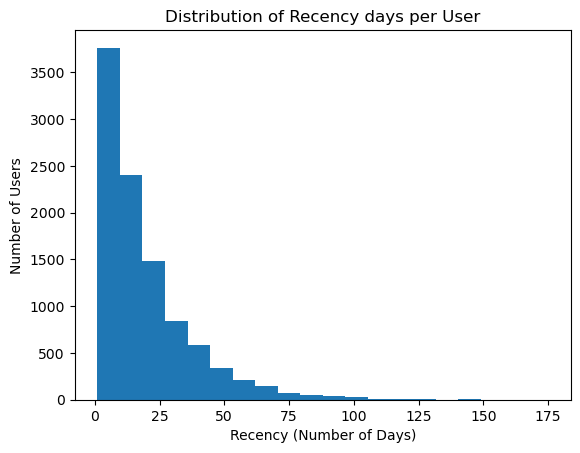

In [428]:
# Recency histogram

plt.hist(rfms["recency_days"], bins=20)
plt.xlabel("Recency (Number of Days)")
plt.ylabel("Number of Users")
plt.title("Distribution of Recency days per User")
plt.show()

#### ***Insights:***
**Recency:** The distribution exhibits a positive skew toward lower recency values, suggesting that the majority of users remain recently active. Nonetheless, individuals with elevated recency levels may signal declining engagement and potential churn risk.

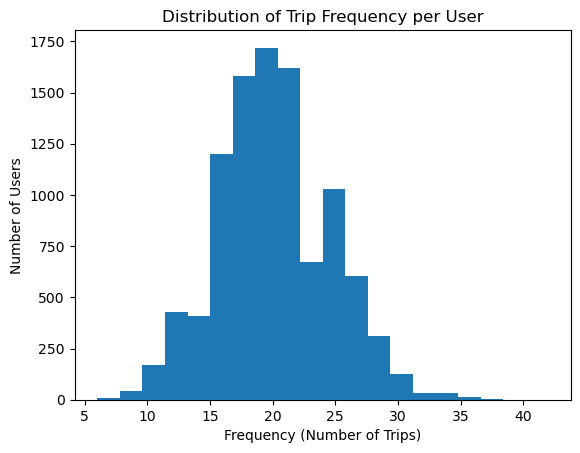

In [430]:
# Frequency histogram

plt.hist(rfms["frequency"], bins=20)
plt.xlabel("Frequency (Number of Trips)")
plt.ylabel("Number of Users")
plt.title("Distribution of Trip Frequency per User")
plt.show()

#### ***Insights:***

**Frequency:**  The near-normal distribution suggests a stable spread of user activity, with a central concentration around 20 trips per customer. Deviations from this midpoint may identify segments of strategic interest, including highly engaged users and those at potential risk of churning.

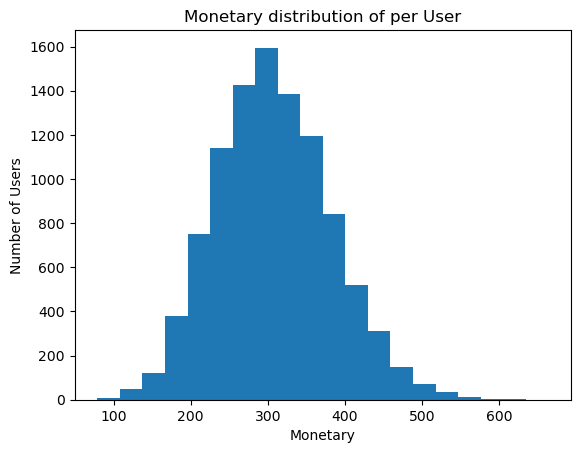

In [432]:
# Monetary histogram

plt.hist(rfms["monetary"], bins=20)
plt.xlabel("Monetary")
plt.ylabel("Number of Users")
plt.title("Monetary distribution of per User")
plt.show()

#### ***Insights:***

**Monetary:**  The monetary distribution is similar to the frequency trend, with a central concentration. This alignment reinforces segmentation reliability and provides a solid foundation for pricing optimization.

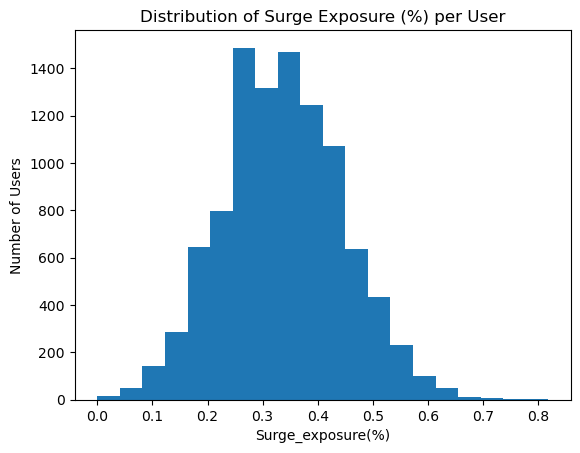

In [434]:
# Percentage Surge Exposure histogram

plt.hist(rfms["surge_exposure"], bins=20)
plt.xlabel("Surge_exposure(%)")
plt.ylabel("Number of Users")
plt.title("Distribution of Surge Exposure (%) per User")
plt.show()

#### ***Insights:***

**Surge Exposure (%):**  The plot shows a symmetrical distribution (No Skew). This suggests moderate exposure for most users and elevated exposure for a distinct subset. Further analysis of its relationship with retention and engagement could inform pricing and loyalty optimization efforts.

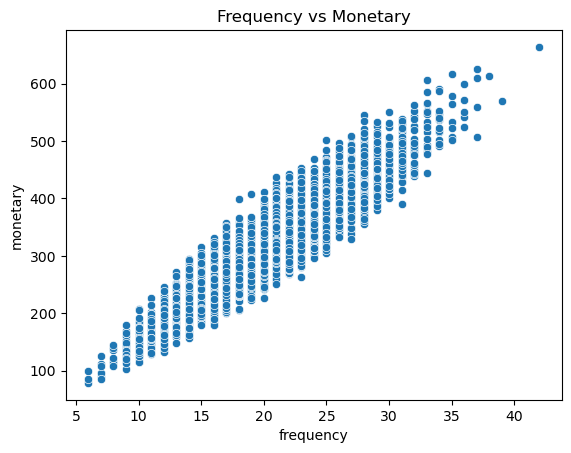

In [436]:
# Relationship between Frequency and Monetary

sns.scatterplot(data=rfms, x='frequency', y='monetary')
plt.title("Frequency vs Monetary")
plt.show()

**Insight:**
There is a strong positive relationship between trip frequency and total spending, showing that frequent riders contribute significantly more revenue.

#### Assign RFMS scores(quantiles 1-4)

I score each metric using quantiles (divide customers into 5 equal groups):

- R score: 4 = most recent, 1 = least recent (inverted because lower recency days = better)
- F score: 4 = most frequent, 1 = least frequent
- M score: 4 = highest spender, 1 = lowest spender
- S score: 4 = highest surge exposure, 1 = lowest surge exposure

In [439]:
rfms["R_score"] = pd.qcut(rfms["recency_days"].rank(method="first"), 4, labels=[4,3,2,1]).astype(int)
rfms["F_score"] = pd.qcut(rfms["frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfms["M_score"] = pd.qcut(rfms["monetary"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfms["S_score"] = pd.qcut(rfms["surge_exposure"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)

rfms["RFMS"] = rfms["R_score"].astype(str) + rfms["F_score"].astype(str) + rfms["M_score"].astype(str) + rfms["S_score"].astype(str)

rfms.head()

,user_id,recency_days,frequency,monetary,surge_exposure,R_score,F_score,M_score,S_score,RFMS
0,R00000,26,25,366.05,0.280000,2,4,4,2,2442
1,R00001,6,14,180.53,0.214286,4,1,1,1,4111
2,R00002,15,24,378.99,0.375000,2,4,4,3,2443
3,R00003,62,9,121.47,0.333333,1,1,1,2,1112
4,R00004,13,16,268.43,0.437500,3,1,2,4,3124


In [440]:
# Calculate combined RFMS score

rfms['RFMS_score'] = rfms[['R_score', 'F_score', 'M_score', 'S_score']].sum(axis=1)
rfms.head()

,user_id,recency_days,frequency,monetary,surge_exposure,R_score,F_score,M_score,S_score,RFMS,RFMS_score
0,R00000,26,25,366.05,0.280000,2,4,4,2,2442,12
1,R00001,6,14,180.53,0.214286,4,1,1,1,4111,7
2,R00002,15,24,378.99,0.375000,2,4,4,3,2443,13
3,R00003,62,9,121.47,0.333333,1,1,1,2,1112,5
4,R00004,13,16,268.43,0.437500,3,1,2,4,3124,10


### Map scores to business segments

#### Segment     & 	Risk Level

* Champions	= Very Low Risk
* Active	= Low–Medium Risk
* At Risk	= High Risk
* Dormant   = Very High Risk

In [442]:
# Customer Segmentation

def rfms_segmentation(x):
  if x <= 5:
    return 'Dormant Riders'
  elif x <= 9:
    return 'At Risk Riders'
  elif x <= 13:
    return 'Active Riders'
  else:
    return 'Champions'

rfms['riders_segment'] = rfms['RFMS_score'].apply(rfms_segmentation)
rfms.head()

,user_id,recency_days,frequency,monetary,surge_exposure,R_score,F_score,M_score,S_score,RFMS,RFMS_score,riders_segment
0,R00000,26,25,366.05,0.280000,2,4,4,2,2442,12,Active Riders
1,R00001,6,14,180.53,0.214286,4,1,1,1,4111,7,At Risk Riders
2,R00002,15,24,378.99,0.375000,2,4,4,3,2443,13,Active Riders
3,R00003,62,9,121.47,0.333333,1,1,1,2,1112,5,Dormant Riders
4,R00004,13,16,268.43,0.437500,3,1,2,4,3124,10,Active Riders


### Segment profiles

In [444]:
profiles = rfms.groupby("riders_segment").agg(
    riders=("user_id", "count"),
    avg_recency=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_surge_exposure=("surge_exposure", "mean")
).round(2).sort_values("riders", ascending=False)

profiles

,riders,avg_recency,avg_frequency,avg_monetary,avg_surge_exposure
riders_segment,,,,,
Active Riders,4402,15.28,21.81,338.51,0.35
At Risk Riders,3770,24.18,16.96,255.02,0.31
Champions,1242,6.90,25.42,407.10,0.41
Dormant Riders,586,42.16,14.50,210.12,0.21


### Distribution of riders segments (Visualization)

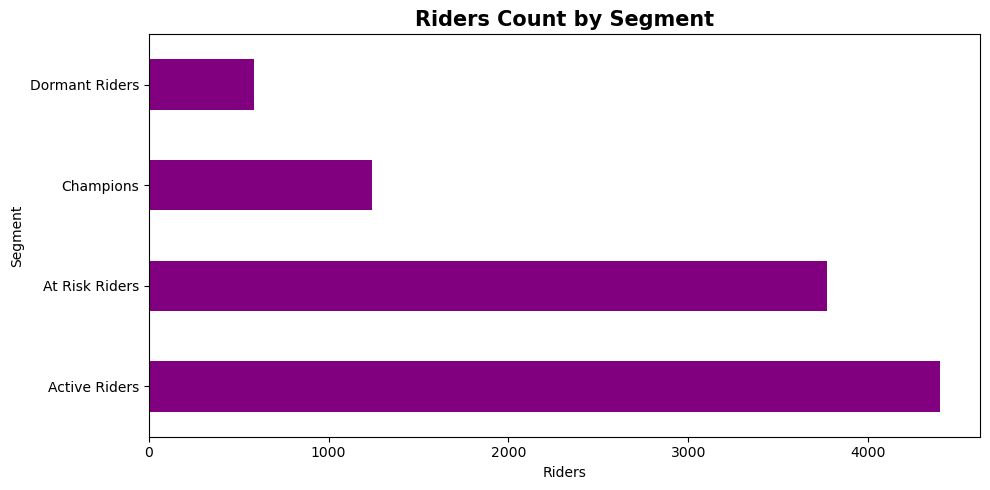

In [446]:
profiles["riders"].plot.barh(figsize=(10, 5), color="purple")
plt.title("Riders Count by Segment", fontsize=15, fontweight="bold")
plt.xlabel("Riders")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

### ***Rider's Segmentation insights***
* **Champions:** High recency, frequency, and monetary value.  → Low churn risk and strongest revenue contributor.
    * Focus on retention and loyalty rewards.
* **Active** Recently engaged with moderate usage and spend. → Stable but can move up or down.
    * Encourage higher frequency and loyalty progression.
* **At Risk:** Declining activity and engagement.  → High churn probability.
    * Focus on retention and loyalty rewards.
* **Dormant** Inactive for a long period with minimal recent value. → Likely churned.
    * Apply selective win-back strategies.

### **Implementing a Weighted Score in the RFMS Analysis**

#### The weighted score will be calculated by assigning different importance levels to each RFMS component:

* Recency is weighted at 40% (0.4), reflecting its critical role in identifying churn risk.

* Frequency carries a 30% (0.3) weight, capturing engagement intensity.

* Monetary is assigned 20% (0.2), representing overall spending contribution.

* Surge is weighted at 10% (0.1), accounting for exposure to surge pricing.

The weighted components are combined to form a single composite score and will be rounded to two decimal places.

This weighted score creates a more refined customer evaluation metric, giving greater emphasis to Recency, which is an essential predictor of churn. While still incorporating frequency, spending behavior, and surge exposure. The result is a more targeted and risk-sensitive segmentation approach.

In [449]:
rfms["weighted_score"] = (
    rfms["R_score"] * 0.4 +
    rfms["F_score"] * 0.3 +
    rfms["M_score"] * 0.2 +
    rfms["S_score"] * 0.1
).round(2)
rfms.head()

,user_id,recency_days,frequency,monetary,surge_exposure,R_score,F_score,M_score,S_score,RFMS,RFMS_score,riders_segment,weighted_score
0,R00000,26,25,366.05,0.280000,2,4,4,2,2442,12,Active Riders,3.0
1,R00001,6,14,180.53,0.214286,4,1,1,1,4111,7,At Risk Riders,2.2
2,R00002,15,24,378.99,0.375000,2,4,4,3,2443,13,Active Riders,3.1
3,R00003,62,9,121.47,0.333333,1,1,1,2,1112,5,Dormant Riders,1.1
4,R00004,13,16,268.43,0.437500,3,1,2,4,3124,10,Active Riders,2.3


### Save the Dataset

In [451]:
RFMS_df = rfms.copy()

RFMS_df.to_csv(r"C:\Users\pehlu\OneDrive\projects\RideWise\Data\RideWise_RFMS_df.csv", index=False)

print('The dataframe was saved successfully')

The dataframe was saved successfully
